In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import statsmodels.api as sm

In [4]:
conn = sqlite3.connect("bike_data.db")
df = pd.read_sql("SELECT * FROM bike_stations", conn)
conn.close()

In [5]:
required_columns = ["distance", "rating", "free bikes"]
missing_columns = [col for col in required_columns if col not in df.columns]

In [6]:
if missing_columns:
    print(f"Warning: The following columns are missing: {missing_columns}")
    for col in missing_columns:
        df[col] = np.nan 

In [7]:
df_cleaned = df.dropna(subset=required_columns)

In [8]:
X = df_cleaned[["distance", "rating"]]
y = df_cleaned["free bikes"]

In [9]:
X = sm.add_constant(X)

In [10]:
model = sm.OLS(y, X).fit()

In [11]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             free bikes   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                -9.063e-12
Date:                Mon, 17 Mar 2025   Prob (F-statistic):               1.00
Time:                        14:54:12   Log-Likelihood:                -45428.
No. Observations:                7500   AIC:                         9.086e+04
Df Residuals:                    7497   BIC:                         9.088e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.6467      3.695     13.705      0.0

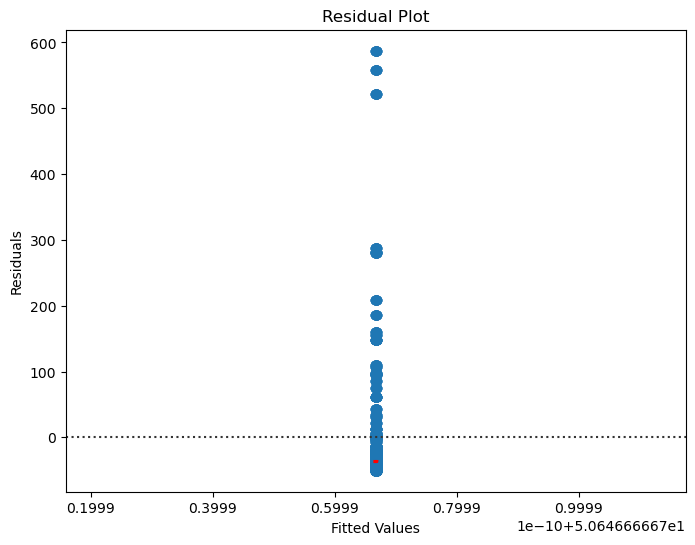

In [12]:
plt.figure(figsize=(8,6))
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, line_kws={"color": "red"})
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

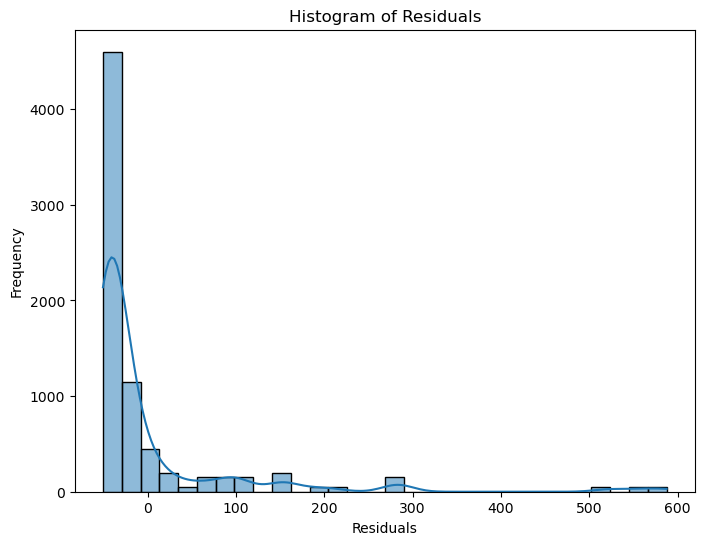

In [13]:
plt.figure(figsize=(8,6))
sns.histplot(model.resid, bins=30, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

Model Interpretation:
- Check the p-values in the regression summary to see which features are significant.
- The residual plots should show no clear patterns if the model fits well.
- If the R-squared value is low, consider additional features or non-linear models.